In [9]:
suppressMessages(library(rwwa))

# Fit linear model to gridded data

In [10]:
# use the same filename from the last workbook
fnm_root = "tx5x-mar-era5"

# load covariate data
gmst = read.table("data/igiss_al_gl_a_4yrlo.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

# define factual & counterfactual covariates
cov_f <- gmst[gmst$year == 2026,"gmst", drop = F]
cov_cf <- rbind("pi" = cov_f - 1.3)

# specify the statistical model you want to fit (should be the same as for your main event definition)
dist <- "gev"
fittype <- "shift"
cov_nm <- "gmst"
lower = F            # use T to look at high extremes, F to look at low extremes

In [4]:
# loop over all flattened data & fit nonstationary model to each - NB no bootstrapping
fl = list.files("flattened", full.names = T)
for(fnm in fl) {
    
    res_fnm <- gsub("flattened", "flattened-res", fnm)
    
    if (!file.exists(res_fnm)) {
        
        # load the .csv and 
        df <- read.csv(fnm, skip = 3, header = F)
        colnames(df)[1] <- "year"
        df$year[1] <- "ev"
        df <- merge(gmst, df, all.y = T)

        # fit nonstationary model to all columns
        models <- sapply(colnames(df)[grepl("V", colnames(df))], function(cnm) {
            df_c <- df[,c("year", "gmst", cnm)]
            df_c <- df_c[!is.na(df_c[,cnm]),]
            tryCatch({
                fit_ns(dist, fittype, data = df_c[!is.na(df_c$gmst),], covnm = cov_nm, varnm = cnm, lower = F,
                       ev = df_c[df_c$year == "ev",cnm], ev_year = 2026)
            }, error = function(cond) { return(NULL) })
        }, simplify = F)

        # get all model results & save as .csv to be reconstructed & plotted in python
        fitted_res <- sapply(models, function(mdl) {
            if(!is.null(unlist(mdl)[1])) {
                mdl_ests(mdl, cov_f = cov_f, cov_cf = cov_cf)
            } else {
                setNames(rep(NA, 11), c('mu0','sigma0','alpha_gmst','shape','disp','event_magnitude','return_period','PR','dI_abs','dI_rel','aic'))
            }})
        write.csv(fitted_res, res_fnm)
    }
}

# Fit linear model to station data

In [ ]:
# load covariate data
gmst = read.table("data/igiss_al_gl_a_4yrlo.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

# define factual & counterfactual covariates
cov_f <- gmst[gmst$year == 2026,"gmst", drop = F]
cov_cf <- rbind("pi" = cov_f - 1.3)

# specify the statistical model you want to fit (should be the same as for your main event definition)
dist <- "gev"
fittype <- "shift"
cov_nm <- "gmst"
lower = F            # use T to look at high extremes, F to look at low extremes

In [ ]:
df <- read.csv("data/station_tx5x.csv")

colnames(df)[1] <- "year"
df$year <- as.integer(substr(df$year,1,4))

df <- merge(gmst, df)

In [17]:
# loop over all stations & fit model
models <- sapply(colnames(df)[grepl("US", colnames(df))], function(cnm) {
    df_c <- df[,c("year", "gmst", cnm)]
    df_c <- df_c[!is.na(df_c[,cnm]),]

    if (nrow(df_c) < 75) return (NULL)
    tryCatch({
        mdl1 <- fit_ns(dist, fittype, df_c, cnm, cov_nm, lower = lower)
        erl <- eff_return_level(mdl1, rp = 100, fixed_cov = cov_f)
        fit_ns(dist, fittype, df_c, cnm, cov_nm, lower = lower, ev = erl, ev_year = 2026)
    }, error = function(cond) { return(NULL) })
}, simplify = F)

In [ ]:
# get all model results & save as .csv to be reconstructed & plotted in python
fitted_res <- sapply(models, function(mdl) {
    if(!is.null(unlist(mdl)[1])) {
        mdl_ests(mdl, cov_f = cov_f, cov_cf = cov_cf)
    } else {
        rep(NA, 11)
    }})

fitted_res <- fitted_res[,!is.na(fitted_res[1,])]
write.csv(fitted_res, "station-trends.csv")

# Scatterplot matrix

In [ ]:
df <- merge(t(read.csv("station-trends.csv", row.names = "X")), read.csv("station-metadata.csv"), by.x = 0, by.y = "station")

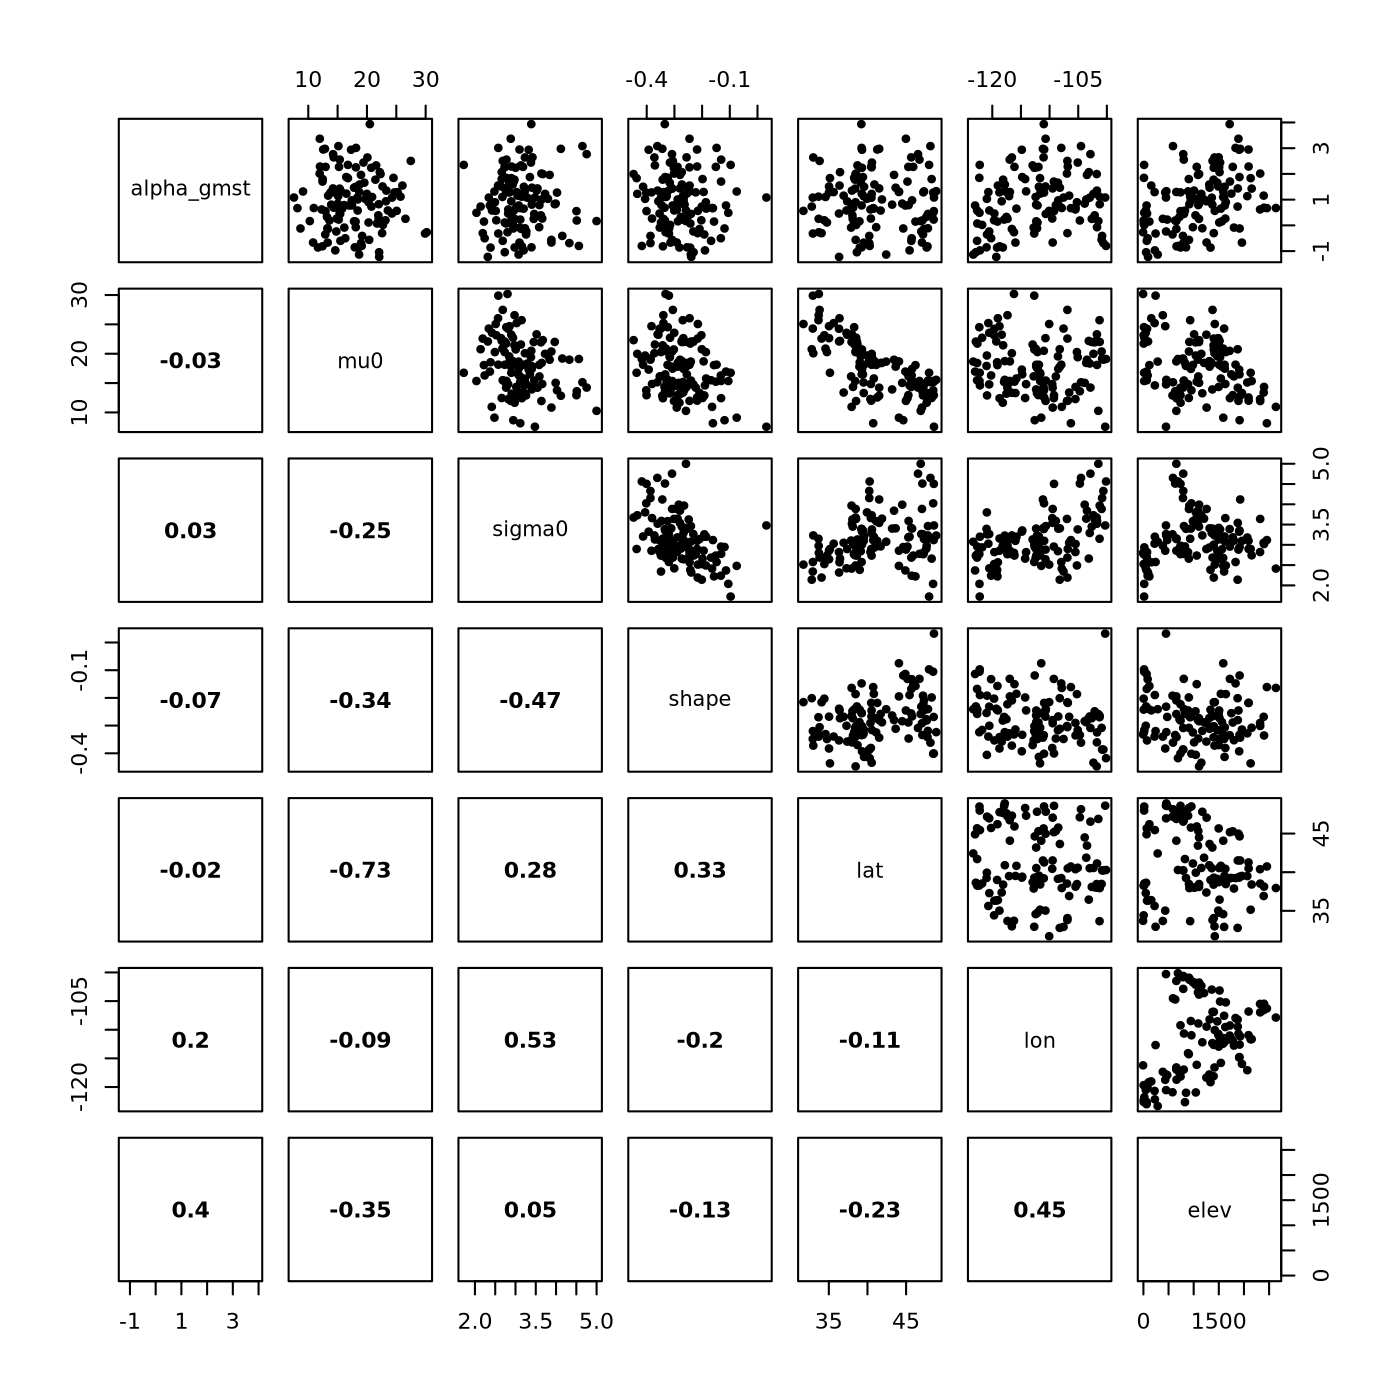

In [56]:
prep_window(h = 7, w = 7)

pairs(df[,c("alpha_gmst", "mu0", "sigma0","shape", "lat", "lon", "elev")], lower.panel = panel.cor)

# Trends per calendar month

In [63]:
df <- read.csv("tx5x-monthly_era5.csv")
df$year <- as.integer(substr(df$time,1,4))
df$month <- as.integer(substr(df$time,6,7))

for (m in 1:12) {
    res_fnm <- paste0("res/res_tx5x-monthly_",formatC(m, width = 2, flag = "0"),".csv")
    # if (file.exists(res_fnm)) next
    df_m <- merge(gmst, df[df$month == m,])[,c("year", "gmst", "tmax")]
    mdl <- fit_ns(dist, fittype, df_m, "tmax", cov_nm, lower = lower)
    res <- boot_ci(mdl, cov_cf, cov_f, nsamp = 1000)
    write.csv(res, res_fnm)
}

In [64]:
df <- read.csv("tmax-monthly_era5.csv")
df$year <- as.integer(substr(df$time,1,4))
df$month <- as.integer(substr(df$time,6,7))

for (m in 1:12) {
    res_fnm <- paste0("res/res_tmax-monthly_",formatC(m, width = 2, flag = "0"),".csv")
    # if (file.exists(res_fnm)) next
    df_m <- merge(gmst, df[df$month == m,])[,c("year", "gmst", "tmax")]
    mdl <- fit_ns(dist, fittype, df_m, "tmax", cov_nm, lower = lower)
    res <- boot_ci(mdl, cov_cf, cov_f, nsamp = 1000)
    write.csv(res, res_fnm)
}

In [65]:
for (varnm in c("tx5x", "tmax")) {
    alpha = t(sapply(list.files("res", varnm, full.names = T), function(fnm) read.csv(fnm, row.names = "X")["alpha_gmst",], simplify = T))
    write.csv(alpha, paste0("alpha_",varnm,"_era5.csv"))
}